## 모듈 불러오기

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 데이터 불러오기

In [2]:
# 데이터 불러오기
df = pd.read_csv('./data/lending_club_preprocessed3.csv')

In [3]:
# 통계검증용 데이터 프레임 생성
stat = df.copy()

## 통계검정 할 변수 결측치 확인

In [7]:
stat[['term', 'issue_year', 'sub_grade']].isna().sum().sort_values(ascending=True)

term          0
issue_year    0
sub_grade     0
dtype: int64

## 통계검정(카이제곱 분석, 조정된 잔차 시각화)

In [ ]:
# 검정할 피처 지정
lst = ['term', 'issue_year', 'sub_grade']

# 교차표 만들기 (적합성 확인)
term_ct = pd.crosstab(df['term'], df['target'])
issue_year_ct = pd.crosstab(df['issue_year'], df['target'])
sub_grade_ct = pd.crosstab(df['sub_grade'], df['target'])

display(term_ct)
display(issue_year_ct)
display(sub_grade_ct)


target,0.0,1.0
term,,
36 months,812242,156859
60 months,207284,101414


target,0.0,1.0
issue_year,,
2012,21630,3995
2013,113775,21023
2014,181938,41159
2015,299741,75804
2016,224853,68252
2017,130148,39168
2018,47441,8872


target,0.0,1.0
sub_grade,,
A1,40170,1337
A2,32992,1602
A3,33201,1899
A4,44190,3247
A5,54788,5020
B1,60868,7075
B2,62406,7979
B3,66202,9931
B4,67104,11718


In [11]:
# 카이제곱 검정

def CramerV(df, col1, col2):
    temp = df.copy()
    ct_test= pd.crosstab(temp[col1], temp[col2])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct_test)
    n = ct_test.sum().sum()
    r, c = ct_test.shape
    df_star = min(r - 1, c - 1)
    cramers_v = np.sqrt(chi2 / (n * df_star))
    return [cramers_v, chi2, p_value, dof, expected]



lst = ['term', 'issue_year', 'sub_grade']
for col in lst:
    print(f'{col}의 통계량, 효과크기 검정')
    #print("기대빈도:\n", expected)
    print(f"카이제곱 통계량: {CramerV(df, col, 'target')[1]:.2f}, ")
    print(f"자유도:         {CramerV(df, col, 'target')[3]}, ")
    print(f"p-value:        {CramerV(df, col, 'target')[2]:.4f}, " )
    print(f"Cramér's V:     {CramerV(df, col, 'target')[0]}, ")
    print(f"기대빈도: {CramerV(df, col, 'target')[4]}, ")
    print('\n','='*50,'\n')

term의 통계량, 효과크기 검정
카이제곱 통계량: 40322.46, 
자유도:         1, 
p-value:        0.0000, 
Cramér's V:     0.17764060553682764, 
기대빈도: [[773223.0703937 195877.9296063]
 [246302.9296063  62395.0703937]], 


issue_year의 통계량, 효과크기 검정
카이제곱 통계량: 5857.47, 
자유도:         6, 
p-value:        0.0000, 
Cramér's V:     0.06770544898119066, 
기대빈도: [[ 20445.58944717   5179.41055283]
 [107552.17819704  27245.82180296]
 [178003.88951783  45093.11048217]
 [299638.59078775  75906.40921225]
 [233861.63882582  59243.36117418]
 [135093.28479362  34222.71520638]
 [ 44930.82843076  11382.17156924]], 


sub_grade의 통계량, 효과크기 검정
카이제곱 통계량: 93586.10, 
자유도:         34, 
p-value:        0.0000, 
Cramér's V:     0.27062904645270847, 
기대빈도: [[33117.46658277  8389.53341723]
 [27601.74522284  6992.25477716]
 [28005.47081348  7094.52918652]
 [37848.87518459  9588.12481541]
 [47719.40736219 12088.59263781]
 [54210.1340023  13732.8659977 ]
 [56158.54880932 14226.45119068]
 [60744.74385878 15388.25614122]
 [62890.23420115 15931.765

### 시각화

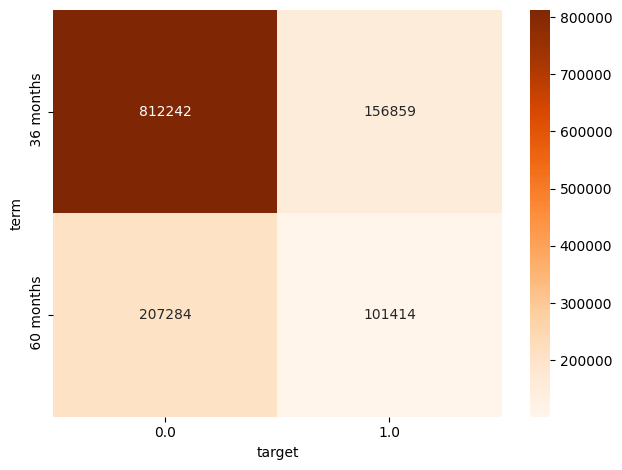

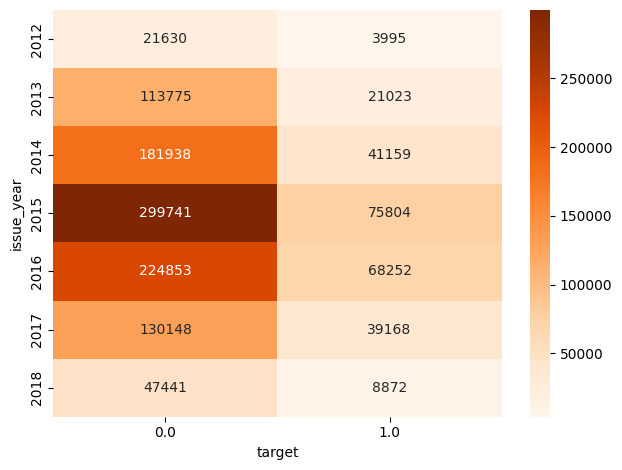

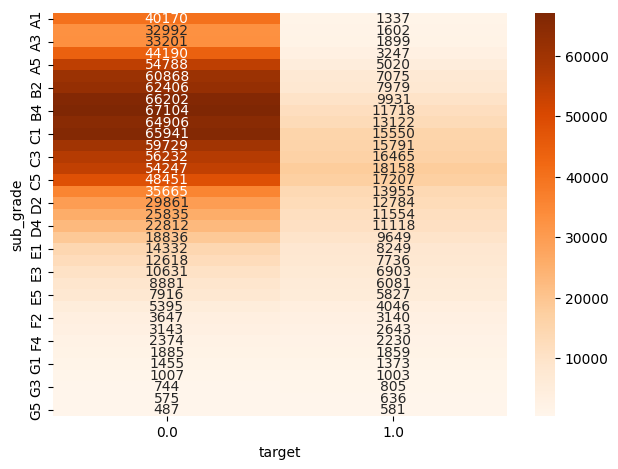

In [ ]:
# 부도 여부와 변수들 히트맵 시각화
for col in lst:
    sns.heatmap(
        pd.crosstab(df[col], df['target']),
        annot=True,
        fmt='d',
        cmap='Oranges'
    )
    plt.tight_layout()
    plt.show()

C:\Users\gmltk\AppData\Local\Temp\ipykernel_218052\2947845023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


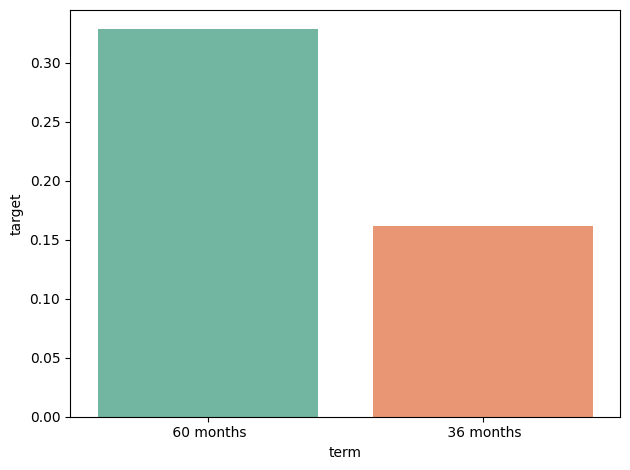

C:\Users\gmltk\AppData\Local\Temp\ipykernel_218052\2947845023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


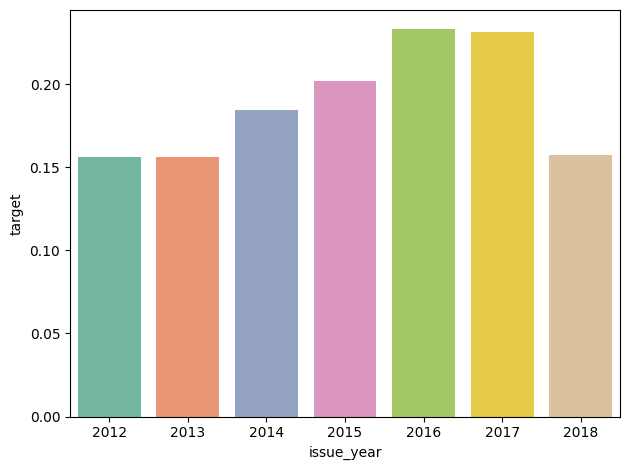

C:\Users\gmltk\AppData\Local\Temp\ipykernel_218052\2947845023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


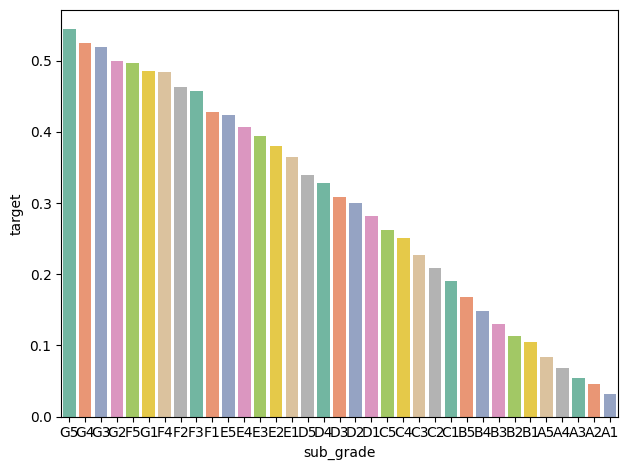

In [13]:
# 부도율 그래프

for col in lst:
    mean_target = df.pivot_table(index=col, values='target').sort_values(by='target', ascending=False)
    sns.barplot(
        x=col,
        y='target',
        data=mean_target,
        palette='Set2'
    )
    plt.tight_layout()
    plt.show()

target,0.0,1.0
term,,
36 months,44.373425,-88.162237
60 months,-78.621362,156.206899


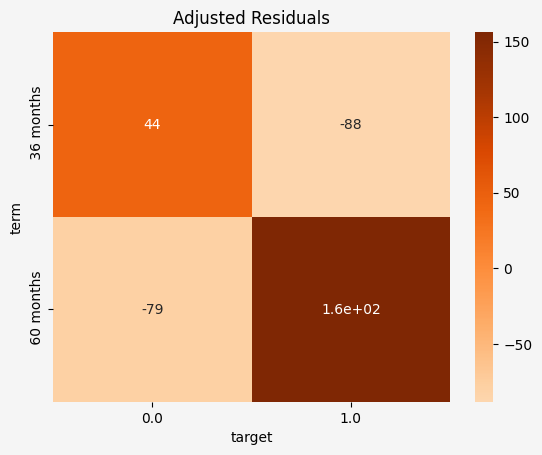

target,0.0,1.0
issue_year,,
2012,8.283282,-16.457433
2013,18.974824,-37.699658
2014,9.324634,-18.526418
2015,0.187086,-0.371706
2016,-18.628577,37.011725
2017,-13.454713,26.732161
2018,11.842167,-23.528316


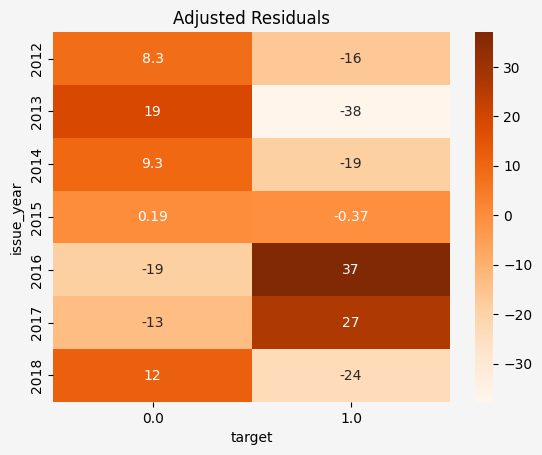

target,0.0,1.0
sub_grade,,
A1,38.754006,-76.997433
A2,32.444495,-64.461539
A3,31.046193,-61.683357
A4,32.594161,-64.758900
A5,32.358280,-64.290245
B1,28.595310,-56.813881
B2,26.363006,-52.378684
B3,22.142160,-43.992601
B4,16.802689,-33.384005


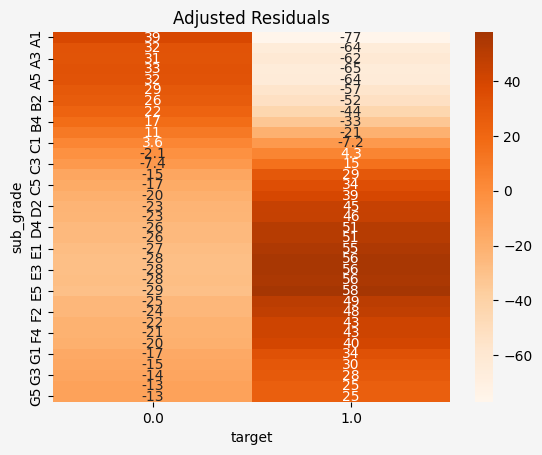

In [17]:
# 카이제곱 검정 & 조정된 잔차 히트맵
for col in lst:
    # 교차표
    table = pd.crosstab(df[col], df['target']).sort_index(ascending=True)

    # 카이제곱 검정
    chi2, p, dof, expected = stats.chi2_contingency(table)

    expected = pd.DataFrame(
        expected,
        index=table.index,
        columns=table.columns
    ).sort_index(ascending=True)
    # 조정된 잔차
    residuals = ((table - expected) / np.sqrt(expected))
    residuals = residuals.sort_index(ascending=True)
    display(residuals)
    
    # 히트맵 시각화
    plt.figure(figsize=(6.4, 4.8), facecolor='whitesmoke')
    sns.heatmap(residuals, annot=True, center=0, cmap='Oranges')
    plt.title("Adjusted Residuals")
    plt.show()